# TP : Implémentation de K-means “from scratch” – Seeds Dataset (UCI)

## Objectif

- Comprendre et implémenter l’algorithme **K-means étape par étape** sans utiliser de bibliothèque de clustering.  
- Appliquer K-means sur le **Seeds Dataset**, un dataset réel avec 3 classes de graines de blé et 7 features numériques.  
- Utiliser **Rand Index (RI)** pour évaluer les performances de Kmeans implémenté 
- Comparer les performances de votre implementation de l'algorithme Kmeans avec 
      -  celles de l'algorithme **K-means de `sklearn`**.   
      -  celles de l'algorithme **DBSCAN de `sklearn`**
  
- Visualiser les clusters en 2D


Télécharger le dataset depuis : https://archive.ics.uci.edu/ml/datasets/seeds 


Répartition des classes :
variety
1    70
2    70
3    70
Name: count, dtype: int64

Lancement de K-means from scratch...
Convergence atteinte après 5 itérations

Rand Index (from scratch) : 0.922
Rand Index (sklearn KMeans) : 0.900
Rand Index (DBSCAN)       : 0.634


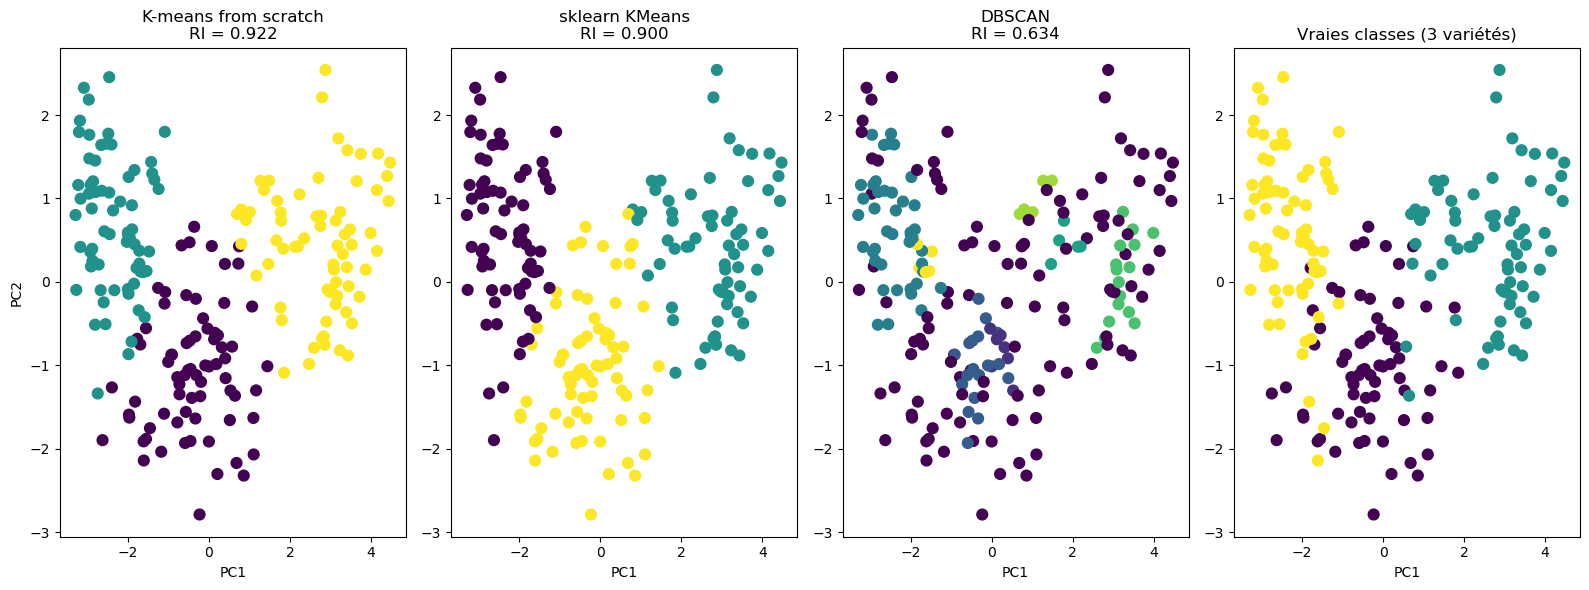


RÉSUMÉ DES PERFORMANCES (Rand Index)
K-means from scratch : 0.922
sklearn KMeans       : 0.900
DBSCAN (eps=0.65)    : 0.634


In [ ]:
# ===================================================================
# TP K-means from scratch – Seeds Dataset (version sans fonction)
# ===================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import rand_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ===================================================================
# 1. Chargement des données (depuis ton fichier datacat.csv ou intégré)
# ===================================================================

# Option 1 : Si ton fichier datacat.csv est dans le même dossier
data = pd.read_csv("datacat.csv")

# Option 2 : Si tu préfères garder le dataset intégré (au cas où le fichier n'est pas trouvé)
# Décommente les lignes ci-dessous si besoin :
# seeds_text = """(colle ici le contenu complet du CSV si tu veux)"""
# data = pd.read_csv(io.StringIO(seeds_text))
print("\nRépartition des classes :")
print(data['variety'].value_counts().sort_index())

# ===================================================================
# 2. Préparation des données
# ===================================================================

X = data.drop('variety', axis=1).values
y_true = data['variety'].values - 1         

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===================================================================
# 3. K-means from scratch – CODE DIRECT SANS FONCTION
# ===================================================================

k = 3
max_iters = 100
tol = 1e-4
random_state = 42
np.random.seed(random_state)

n_samples = X_scaled.shape[0]
# Initialisation aléatoire des centroïdes
idx = np.random.choice(n_samples, k, replace=False)
centroids = X_scaled[idx].copy()

print("\nLancement de K-means from scratch...")
for iteration in range(1, max_iters + 1):
    # Distance euclidienne à tous les centroïdes
    distances = np.linalg.norm(X_scaled[:, np.newaxis] - centroids, axis=2)
    labels_scratch = np.argmin(distances, axis=1)
    
    # Mise à jour des centroïdes
    new_centroids = np.zeros_like(centroids)
    for i in range(k):
        if np.sum(labels_scratch == i) > 0:
            new_centroids[i] = X_scaled[labels_scratch == i].mean(axis=0)
        else:
            new_centroids[i] = centroids[i]  # garde l'ancien si cluster vide
    
    # Vérification de la convergence
    if np.all(np.linalg.norm(new_centroids - centroids, axis=1) < tol):
        break
    
    centroids = new_centroids

# ===================================================================
# 4. Évaluation
# ===================================================================

ri_scratch = rand_score(y_true, labels_scratch)
print(f"\nRand Index (from scratch) : {ri_scratch:.3f}")

# Sklearn K-means
kmeans_sk = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sk = kmeans_sk.fit_predict(X_scaled)
ri_sk = rand_score(y_true, labels_sk)
print(f"Rand Index (sklearn KMeans) : {ri_sk:.3f}")

# DBSCAN
dbscan = DBSCAN(eps=0.65, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
ri_db = rand_score(y_true, labels_db)
print(f"Rand Index (DBSCAN)       : {ri_db:.3f}")

# ===================================================================
# 5. Visualisation PCA 2D
# ===================================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(16, 6))

# K-means from scratch
plt.subplot(1, 4, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_scratch, cmap='viridis', s=60)
plt.title(f'K-means from scratch\nRI = {ri_scratch:.3f}')
plt.xlabel('PC1'); plt.ylabel('PC2')

# sklearn KMeans
plt.subplot(1, 4, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sk, cmap='viridis', s=60)
plt.title(f'sklearn KMeans\nRI = {ri_sk:.3f}')
plt.xlabel('PC1')

# DBSCAN
plt.subplot(1, 4, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='viridis', s=60)
plt.title(f'DBSCAN\nRI = {ri_db:.3f}')
plt.xlabel('PC1')

# Vraies classes
plt.subplot(1, 4, 4)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=60)
plt.title('Vraies classes (3 variétés)')
plt.xlabel('PC1')

plt.tight_layout()
plt.show()

# ===================================================================
# Résumé final
# ===================================================================

print("\n" + "="*60)
print("RÉSUMÉ DES PERFORMANCES (Rand Index)")
print("="*60)
print(f"K-means from scratch : {ri_scratch:.3f}")
print(f"sklearn KMeans       : {ri_sk:.3f}")
print(f"DBSCAN (eps=0.65)    : {ri_db:.3f}")
print("="*60)